# Product Review Analysis Pipeline Summary
Collects reviews from the web, runs sentiment analysis on product features, and compiles product requirements.

**Steps:**
1. Enter a product name
2. Collect reviews from the web (via SerpAPI Google Shopping)
3. Run HuggingFace sentiment analysis on features
4. Compile product requirements from review insights
5. Save everything to Excel on Google Drive

## Install dependencies

In [ ]:
!pip install -q transformers torch sentencepiece openpyxl serpapi google-search-results requests pandas

  Preparing metadata (setup.py) ... done


## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Set working directory

In [ ]:
%cd /content/drive/MyDrive/AIDS_proj2/

/content/drive/MyDrive/AIDS_proj2


## Load API Keys

In [ ]:
import os

# OpenAI key (used for requirements generation via LLM)
f = open('keys/open_ai2.txt', 'r')
openai_key = f.readlines()[0].strip()
f.close()


# SerpAPI key (used to fetch Google Shopping / review results)
f = open('keys/serpapi_key.txt', 'r')
serpapi_key = f.readlines()[0].strip()
f.close()

print('Keys loaded.')

Keys loaded.


---
## 1 — User Input: Enter the Product

In [ ]:
product_name = input('Enter product name (e.g. "Sony WH-1000XM5"): ').strip()
max_reviews = 50  #each page ~10 reviews

print(f'\nProduct: {product_name}')
print(f'Target reviews: {max_reviews}')

Enter product name (e.g. "Sony WH-1000XM5"): Toilet Bowl

Product: Toilet Bowl
Target reviews: 50



## 2 — Data Collection: Fetch Reviews from the Web

Uses SerpAPI to query Google Shopping product reviews.
Falls back to a Google search scrape if no product page is found.

In [ ]:
import requests
import pandas as pd
import time

def fetch_reviews_generic(product_name, serpapi_key, max_reviews=50):
    reviews = []
    search_url = 'https://serpapi.com/search'

    queries = [
        f'{product_name} review',
        f'{product_name} thoughts',
        f'{product_name} user review pros cons',
        f'{product_name} review rating',
        f'{product_name} review 2024',
        f'best {product_name} review'
    ]

    for q in queries:
        if len(reviews) >= max_reviews:
            break

        print(f'  Searching: "{q}"')
        params = {
            'engine': 'google',
            'q': q,
            'api_key': serpapi_key,
            'num': 10
        }
        try:
            resp = requests.get(search_url, params=params)
            data = resp.json()

            if 'error' in data:
                print(f'  API error: {data["error"]}')
                break

            for result in data.get('organic_results', []):
                snippet = result.get('snippet', '')
                if snippet and len(snippet) > 30:
                    reviews.append({
                        'source': result.get('source', 'Web'),
                        'rating': None,
                        'title': result.get('title', ''),
                        'content': snippet,
                        'date': result.get('date', '')
                    })

        except Exception as e:
            print(f'  Error on query "{q}": {e}')

        time.sleep(0.5)

    print(f'\nTotal reviews collected: {len(reviews)}')
    return reviews[:max_reviews]


# Run
reviews = fetch_reviews_generic(product_name, serpapi_key, max_reviews)
df_reviews = pd.DataFrame(reviews)
print(df_reviews.head(3))

  Searching: "Toilet Bowl review"
  Searching: "Toilet Bowl throughts"
  Searching: "Toilet Bowl user review pros cons"
  Searching: "Toilet Bowl review rating"
  Searching: "Toilet Bowl review 2024"
  Searching: "best Toilet Bowl review"

Total reviews collected: 48
                   source rating  \
0        Consumer Reports   None   
1  Better Homes & Gardens   None   
2     Reddit · r/Plumbing   None   

                                               title  \
0    9 Best Toilets of 2026, Lab-Tested and Reviewed   
1  After Months of Testing, These Are the 6 Best ...   
2  What do real plumbers recommend for toilets? :...   

                                             content          date  
0  The best toilets in CR's tests can clear out s...  Feb 18, 2026  
1  The toilet features a strong flush that consis...                
2  Yup they're a good price for the quality and e...                


## Save raw reviews to Excel

In [ ]:
import os

# Create output folder
safe_name = product_name.replace(' ', '_').replace('/', '-')
output_dir = f'output/{safe_name}'
os.makedirs(output_dir, exist_ok=True)

reviews_path = f'{output_dir}/01_raw_reviews.xlsx'
df_reviews.to_excel(reviews_path, index=False)
print(f'Raw reviews saved to: {reviews_path}')

Raw reviews saved to: output/Toilet_Bowl/01_raw_reviews.xlsx


---
## 3 — Define Product Features to Analyse

These are the aspects/features the sentiment model will score.
Edit this list to match the product category.

In [ ]:
# CUSTOMISE: Add or remove features relevant to the product
# can comment out to have specific features
# features = [
#     'sound quality',
#     'battery life',
#     'comfort',
#     'build quality',
#     'noise cancellation',
#     'connectivity',
#     'price',
#     'design',
#     'microphone',
#     'ease of use'
# ]

# Auto-generate features using OpenAI

USE_AUTO_FEATURES = True

if USE_AUTO_FEATURES:
    from openai import OpenAI
    client = OpenAI(api_key=openai_key)
    prompt = f"""List 8-10 key features or aspects that users typically care about when reviewing a '{product_name}'.
    Return ONLY a Python list of short lowercase strings, like: [\"battery life\", \"sound quality\", ...]"""
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'user', 'content': prompt}]
    )
    import ast
    # Clean the response to remove markdown code block formatting if present
    cleaned_response_content = response.choices[0].message.content.strip().replace('```python', '').replace('```', '').strip()
    features = ast.literal_eval(cleaned_response_content)

print('Features to analyse:')
for i, f in enumerate(features, 1):
    print(f'  {i}. {f}')

Features to analyse:
  1. flush performance
  2. water efficiency
  3. comfort height
  4. bowl shape
  5. ease of cleaning
  6. noise level
  7. durability
  8. installation ease
  9. price
  10. design


---
##4 Sentiment Analysis with HuggingFace

Uses `cardiffnlp/twitter-roberta-base-sentiment` .
For each review, it finds sentences mentioning each feature and scores them.

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
import re
from collections import defaultdict

# Load model (downloads ~500MB on first run, then cached)
print('Loading sentiment model...')
MODEL = 'cardiffnlp/twitter-roberta-base-sentiment'
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Labels: LABEL_0 = Negative, LABEL_1 = Neutral, LABEL_2 = Positive
LABEL_MAP = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}

print('Model loaded.')
print(f'GPU available: {torch.cuda.is_available()}')

Loading sentiment model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/config.json
Retrying in 2s [Retry 2/5].


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
HTTP Error 504 thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].


vocab.json: 0.00B [00:00, ?B/s]

...

HTTP Error 504 thrown while requesting HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/main/model.safetensors.index.json
Retrying in 1s [Retry 1/5].


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
GPU available: False


In [ ]:
def split_sentences(text):
    """Simple sentence splitter."""
    return [s.strip() for s in re.split(r'[.!?]', str(text)) if len(s.strip()) > 10]

def score_sentiment(text):
    """Returns a score: -1 (negative), 0 (neutral), +1 (positive)."""
    try:
        result = sentiment_pipeline(text[:512])[0]
        label_score = LABEL_MAP.get(result['label'], 0)
        # Weight by confidence
        return label_score * result['score']
    except Exception:
        return 0.0

def analyse_features(reviews_df, features):
    """For each feature, find relevant sentences and compute average sentiment."""
    feature_scores = defaultdict(list)   # feature -> list of sentiment scores
    feature_mentions = defaultdict(list) # feature -> list of example sentences

    total = len(reviews_df)
    for idx, row in reviews_df.iterrows():
        if idx % 10 == 0:
            print(f'  Analysing review {idx+1}/{total}...')

        text = str(row.get('content', '')) + ' ' + str(row.get('title', ''))
        sentences = split_sentences(text)

        for sentence in sentences:
            sentence_lower = sentence.lower()
            for feature in features:
                # Check if feature (or any of its keywords) appears in the sentence
                feature_keywords = feature.split()
                if any(kw in sentence_lower for kw in feature_keywords):
                    score = score_sentiment(sentence)
                    feature_scores[feature].append(score)
                    if len(feature_mentions[feature]) < 5:  # keep up to 5 examples
                        feature_mentions[feature].append(sentence.strip())

    return feature_scores, feature_mentions


print('Running sentiment analysis on features...')
feature_scores, feature_mentions = analyse_features(df_reviews, features)

print('\nDone! Feature mention counts:')
for f in features:
    print(f'  {f}: {len(feature_scores[f])} mentions')

Running sentiment analysis on features...
  Analysing review 1/47...
  Analysing review 11/47...
  Analysing review 21/47...
  Analysing review 31/47...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/usr/local/lib/python3.12/dist-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_sync/connection.py", line 103, in handle_request
    return self._connection.handle_request(request)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/httpcore/_syn

  Analysing review 41/47...

Done! Feature mention counts:
  flush efficiency: 18 mentions
  water usage: 9 mentions
  comfort height: 7 mentions
  bowl shape: 26 mentions
  ease of cleaning: 39 mentions
  installation process: 2 mentions
  noise level: 4 mentions
  durability: 0 mentions
  design aesthetics: 5 mentions
  price: 2 mentions


## Compile feature sentiment summary

In [ ]:
import numpy as np

summary_rows = []
for feature in features:
    scores = feature_scores[feature]
    if scores:
        avg = np.mean(scores)
        positive_pct = sum(1 for s in scores if s > 0.1) / len(scores) * 100
        negative_pct = sum(1 for s in scores if s < -0.1) / len(scores) * 100
    else:
        avg, positive_pct, negative_pct = 0, 0, 0

    # Star rating: map [-1, 1] to [1, 5]
    star_rating = round(((avg + 1) / 2) * 4 + 1, 1)

    summary_rows.append({
        'Feature': feature,
        'Mentions': len(scores),
        'Avg Sentiment Score': round(avg, 3),
        'Star Rating (1-5)': star_rating,
        '% Positive': round(positive_pct, 1),
        '% Negative': round(negative_pct, 1),
        'Example Mentions': ' | '.join(feature_mentions[feature][:3])
    })

df_sentiment = pd.DataFrame(summary_rows).sort_values('Avg Sentiment Score', ascending=False)
print(df_sentiment[['Feature', 'Star Rating (1-5)', 'Mentions', '% Positive', '% Negative']].to_string(index=False))

             Feature  Star Rating (1-5)  Mentions  % Positive  % Negative
      comfort height                4.2         7        85.7         0.0
    flush efficiency                4.1        18        72.2         0.0
   design aesthetics                4.1         5        60.0         0.0
               price                3.9         2        50.0         0.0
    ease of cleaning                3.8        39        53.8         5.1
          bowl shape                3.8        26        61.5         3.8
         water usage                3.7         9        44.4         0.0
installation process                3.0         2         0.0         0.0
          durability                3.0         0         0.0         0.0
         noise level                3.0         4         0.0         0.0


---
## 5 — Generate Product Requirements

Uses GPT-4o to read the reviews and extract concrete product requirements
(e.g. "Battery should last at least 30 hours", "Weight should be under 250g").

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=openai_key)

# Prepare review sample for the LLM (trim to keep tokens manageable)
review_sample = df_reviews['content'].dropna().tolist()[:30]
review_text = '\n---\n'.join(review_sample)

# Prepare sentiment summary
sentiment_summary = df_sentiment[['Feature', 'Star Rating (1-5)', '% Positive', '% Negative', 'Example Mentions']].to_string(index=False)

prompt = f"""You are a product designer. Based on the real user reviews and sentiment analysis below for the product '{product_name}', extract a list of product requirements.

Each requirement should:
- Be specific and measurable where possible (e.g. "Battery life should exceed 30 hours")
- Reference what users actually complained about or praised
- Cover functional, physical, and experiential aspects

--- SENTIMENT ANALYSIS SUMMARY ---
{sentiment_summary}

--- SAMPLE USER REVIEWS ---
{review_text[:4000]}

Output a numbered list of 10-15 product requirements. Format each as:
[Category] Requirement description

Example:
[Battery] Battery life should exceed 30 hours on a single charge.
[Comfort] Ear cushions should use memory foam or equivalent soft material.
[Price] Retail price should be competitive with similar-tier products."""

print('Generating product requirements with GPT-4o...')
response = client.chat.completions.create(
    model='gpt-4o',
    messages=[{'role': 'user', 'content': prompt}],
    temperature=0.3
)

requirements_text = response.choices[0].message.content
print('\n--- PRODUCT REQUIREMENTS ---')
print(requirements_text)

Generating product requirements with GPT-4o...

--- PRODUCT REQUIREMENTS ---
1. [Comfort] The toilet bowl should have an elongated shape to enhance user comfort, as it is longer than a round bowl and preferred by most users.

2. [Flush Efficiency] The toilet should clear out solid waste and clean the bowl effectively with one flush, achieving a flush efficiency rating of at least 4.1 stars.

3. [Design Aesthetics] The toilet should feature a sleek, modern design, such as a rimless style, to enhance the overall look of a bathroom.

4. [Price] The retail price of the toilet should be competitive, ideally ranging from $199 to $500, to appeal to budget-conscious consumers.

5. [Ease of Cleaning] The toilet design should facilitate easy cleaning, potentially incorporating self-cleaning features to reduce the need for manual scrubbing.

6. [Bowl Shape] The toilet should offer both elongated and round bowl options to accommodate different bathroom sizes and user preferences.

7. [Water Usage]

In [ ]:
# Parse requirements into a structured DataFrame
import re

req_rows = []
for line in requirements_text.strip().split('\n'):
    line = line.strip()
    if not line:
        continue
    # Match lines like: 1. [Category] Description  OR  [Category] Description
    match = re.match(r'^(?:\d+\.?\s*)?\[([^\]]+)\]\s*(.+)$', line)
    if match:
        req_rows.append({
            'Category': match.group(1).strip(),
            'Requirement': match.group(2).strip(),
            'Priority': '',  # Can be manually filled in
            'Source': 'User Reviews'
        })
    elif re.match(r'^\d+\.\s*.+', line):
        req_rows.append({
            'Category': 'General',
            'Requirement': re.sub(r'^\d+\.\s*', '', line),
            'Priority': '',
            'Source': 'User Reviews'
        })

df_requirements = pd.DataFrame(req_rows)
print(f'\nParsed {len(df_requirements)} requirements.')
print(df_requirements[['Category', 'Requirement']].to_string(index=False))


Parsed 15 requirements.
            Category                                                                                                                                               Requirement
             Comfort                    The toilet bowl should have an elongated shape to enhance user comfort, as it is longer than a round bowl and preferred by most users.
    Flush Efficiency         The toilet should clear out solid waste and clean the bowl effectively with one flush, achieving a flush efficiency rating of at least 4.1 stars.
   Design Aesthetics                                     The toilet should feature a sleek, modern design, such as a rimless style, to enhance the overall look of a bathroom.
               Price                         The retail price of the toilet should be competitive, ideally ranging from $199 to $500, to appeal to budget-conscious consumers.
    Ease of Cleaning              The toilet design should facilitate easy cleaning, potentially inc

---
## 6 — Save Everything to Excel (Multi-sheet)

In [ ]:
output_path = f'{output_dir}/product_analysis.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # Sheet 1: Raw Reviews
    df_reviews.to_excel(writer, sheet_name='Raw Reviews', index=False)

    # Sheet 2: Feature Sentiment
    df_sentiment.to_excel(writer, sheet_name='Feature Sentiment', index=False)

    # Sheet 3: Product Requirements
    df_requirements.to_excel(writer, sheet_name='Product Requirements', index=False)

    # Sheet 4: Summary
    summary_df = pd.DataFrame({
        'Field': ['Product', 'Reviews Collected', 'Features Analysed', 'Requirements Generated'],
        'Value': [product_name, len(df_reviews), len(features), len(df_requirements)]
    })
    summary_df.to_excel(writer, sheet_name='Summary', index=False)

print(f'\nAll results saved to: {output_path}')
print('\nSheets:')
print('  - Raw Reviews')
print('  - Feature Sentiment')
print('  - Product Requirements')
print('  - Summary')


All results saved to: output/Toilet_Bowls/product_analysis.xlsx

Sheets:
  - Raw Reviews
  - Feature Sentiment
  - Product Requirements
  - Summary


---
## Quick Visual Summary

Bar chart of feature sentiment ratings.

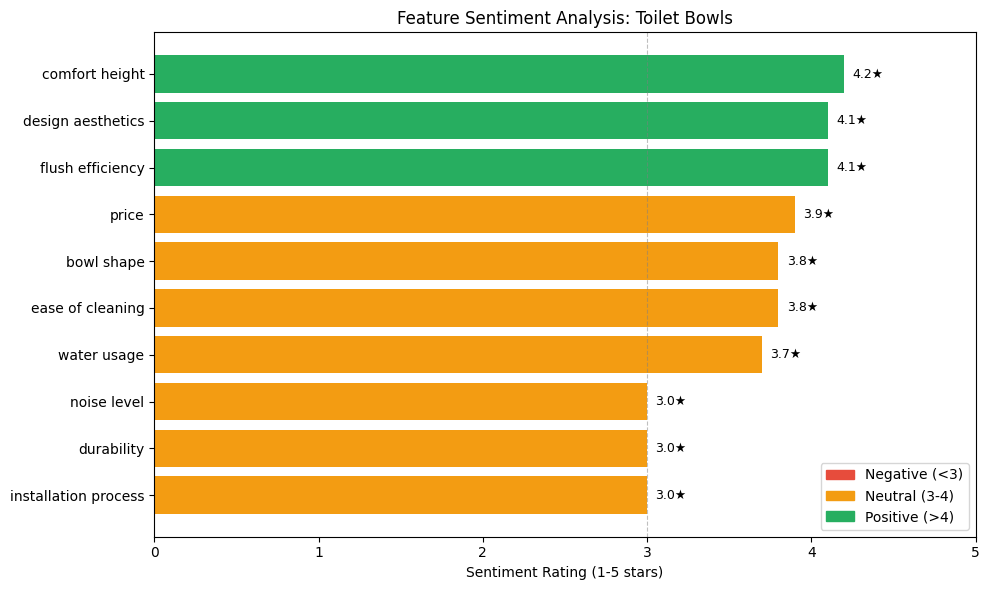

Chart saved to: output/Toilet_Bowls/feature_sentiment_chart.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_plot = df_sentiment.sort_values('Star Rating (1-5)', ascending=True)

colors = ['#e74c3c' if r < 3 else '#f39c12' if r < 4 else '#27ae60'
          for r in df_plot['Star Rating (1-5)']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['Feature'], df_plot['Star Rating (1-5)'], color=colors)
ax.set_xlim(0, 5)
ax.axvline(x=3, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Sentiment Rating (1-5 stars)')
ax.set_title(f'Feature Sentiment Analysis: {product_name}')

# Add value labels
for bar, val in zip(bars, df_plot['Star Rating (1-5)']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}★', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Negative (<3)'),
    mpatches.Patch(color='#f39c12', label='Neutral (3-4)'),
    mpatches.Patch(color='#27ae60', label='Positive (>4)')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()

chart_path = f'{output_dir}/feature_sentiment_chart.png'
plt.savefig(chart_path, dpi=150)
plt.show()
print(f'Chart saved to: {chart_path}')

---
## Done!

**Output files in the Drive:**
- `output/<product_name>/product_analysis.xlsx` — Full results (4 sheets)
- `output/<product_name>/feature_sentiment_chart.png` — Bar chart